# Pre-lab 1: Failure Modes, Calibration, and the Equation Design: SOLUTION KEY
### ME 323 Module 1 (staff only)

<img src="https://raw.githubusercontent.com/andrewvoss8-boop/core-me-data-science-activities-public/main/me323/Module1_drafts/figures/I_beam_dimensions.jpg" alt="I-beam dimensions" width="260">

In the image, `b` is web thickness, `H` is web height, `B` is flange width,
and the image's `h` is the flange thickness called `t_f` in this notebook.

You will load the class beam data, compute strength-to-weight, code the
failure-mode formulas, inspect where they disagree with real failures, tune
the parameters by hand, calibrate them, and optimize the class equation design.

Lines marked `FILL IN` are yours. Each step prints a checkpoint.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120

# Fixed geometry (you choose b and H_web; everything else is set)
B, TH, L = 10.0, 18.0, 150.0     # flange width, total height, test span (mm)
LP = 172.0                        # printed length (mm); overhangs the 150 mm span
KMASS = 0.2045                    # g/mm^2: mass per unit cross-section area at 172 mm

# Handbook starting values — Pre-lab 1 calibrates the three marked ones
SY = 76e6                         # Pa, PLA strength                 (calibrated)
K_LTB = 0.33                      # fixture effective-length factor  (calibrated)
TAU_I = 43.9e6                    # printed-interface shear strength (Pa) — starting
                                  # guess = bulk yield / sqrt(3)     (calibrated)
E, G = 2.5e9, 2.5e9 / 2.6         # Young's / shear modulus (Pa) — fixed
C1, C2 = 1.35, 0.55               # LTB moment-gradient / load-height factors
print("Constants loaded. Nominal SY =", SY/1e6, "MPa")

Constants loaded. Nominal SY = 76.0 MPa


## 1. The data

These are fifteen real three-point-bend tests. The beams were printed at
172 mm and tested on a 150 mm support span. `failure_note` is the test engineer's
observation, not a model-generated label. `weight_g` is measured; `mass_est_g`
comes from nominal geometry. They should not be identical. Read the notes and
the mass discrepancy before fitting anything. One quirk: beam 15's measured
weight was never recorded, so its mass columns read NaN. Every
strength-to-weight number in this module uses estimated mass, so nothing
downstream depends on that missing measurement.

In [2]:
URL = ("https://raw.githubusercontent.com/andrewvoss8-boop/"
       "core-me-data-science-activities-public/main/data/student_beams_B10_L150.csv")
try:
    df = pd.read_csv(URL); print("loaded from GitHub")
except Exception:
    try:
        df = pd.read_csv("student_beams_B10_L150.csv"); print("loaded local copy")
    except FileNotFoundError as e:
        raise FileNotFoundError(
            "no internet and no local copy -- download student_beams_B10_L150.csv "
            "from the course page into this notebook's folder and rerun") from e
df = df.rename(columns={"b_mm": "b", "H_web_mm": "H"})

def estimated_mass_g(b, H):
    A = b * H + B * (TH - H)      # cross-section area, mm^2
    return KMASS * A              # grams
df["mass_est_g"] = estimated_mass_g(df.b, df.H)
df["mass_delta_g"] = df.weight_g - df.mass_est_g
df["mass_delta_pct"] = 100*df.mass_delta_g/df.mass_est_g
print(len(df), "tested beams")

pd.set_option("display.max_colwidth", None)
df[["beam_id", "b", "H", "weight_g", "mass_est_g", "mass_delta_pct",
    "strength_N", "failure_note"]].round({"mass_delta_pct": 1})

loaded from GitHub
15 tested beams


,beam_id,b,H,weight_g,mass_est_g,mass_delta_pct,strength_N,failure_note
0,1,7.00,16.0,27.4,26.994000,1.5,829.4,Complete vertical fracture across the center of the beam
1,2,7.00,10.5,30.1,30.368250,-0.9,948.8,Complete vertical fracture across the center of the beam
2,3,4.85,14.4,21.7,21.644280,0.3,724.1,"Vertical fracture on the bottom of the beam, but not completely through the beam"
3,4,3.25,15.1,16.2,15.966337,1.5,588.8,"Vertical fracture on the bottom of the beam, but not completely through the beam"
4,5,3.55,7.5,26.8,26.917312,-0.4,937.4,Complete vertical fracture across the center of the beam
5,6,4.60,13.1,22.3,22.343670,-0.2,759.0,Complete vertical fracture across the center of the beam
6,7,3.70,11.1,22.5,22.509315,-0.0,741.3,Complete vertical fracture across the center of the beam. Small middle part of the top flange also fractured and seperated from the web
7,8,6.40,10.3,29.2,29.227140,-0.1,882.5,Complete vertical fracture across the center of the beam
8,9,1.75,15.8,10.0,10.153425,-1.5,314.4,Twisted off the test stand and flipped over
9,10,5.95,6.3,31.7,31.592182,0.3,918.4,Complete vertical fracture across the center of the beam


## 1b. Where a strength number comes from: reduce four raw traces

Every `strength_N` above was reduced from a force–displacement trace recorded
on the test machine. Here are four of those traces, verbatim from the campaign
(downsampled; the peak row is preserved exactly): beams **6** and **13**
(vertical fracture, complete and partial), beam **14** (flange–web
separation), and beam **9** (the one that twisted off the test stand). Your
group will do this same reduction on your own beam's trace after test day —
so do it here first, where the answer is checkable.

Reduce each trace to one number and compare against the handout column. Then
read the *shapes*: an abrupt cliff after the peak is a fracture; a rounded
peak that sheds load gradually is a different physical story. And look hard at
beam 9 — the machine recorded a peak of 314.4 N, but the beam left
the load path by twisting, not by breaking. Whether that number is a material
strength, a fixture/stability artifact, or both is a judgment call, and every
model downstream of this table inherits whatever you decide.

loaded traces from GitHub


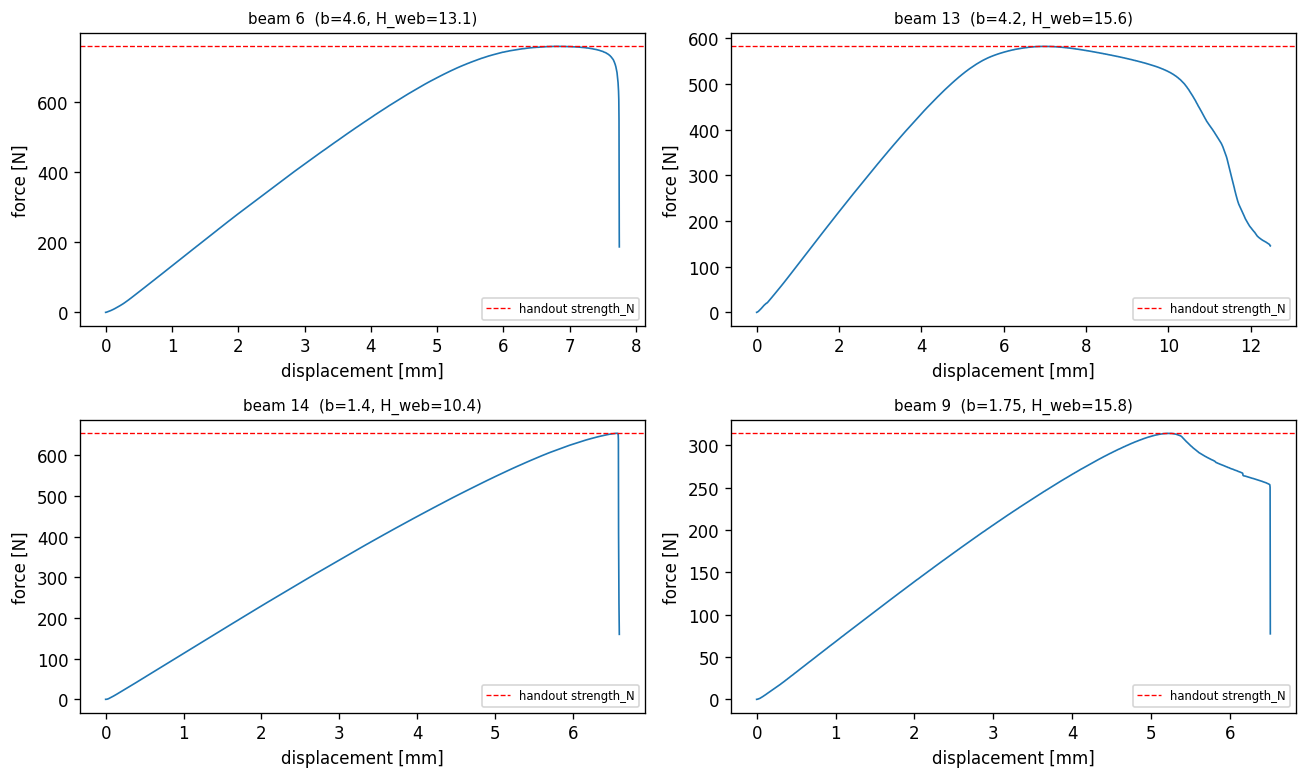

CHECKPOINT: each trace peak should match the handout to 0.1 N
         trace_peak_N  handout_strength_N
beam_id                                  
6               759.0               759.0
9               314.4               314.4
13              582.6               582.6
14              654.6               654.6


In [3]:
TURL = ("https://raw.githubusercontent.com/andrewvoss8-boop/"
        "core-me-data-science-activities-public/main/data/student_traces_4beams.csv")
try:
    tr = pd.read_csv(TURL); print("loaded traces from GitHub")
except Exception:
    tr = pd.read_csv("student_traces_4beams.csv"); print("loaded local traces")

peak_N = tr.groupby("beam_id")["force_N"].max()    # FILL IN (solved)

fig, axes = plt.subplots(2, 2, figsize=(11, 6.6))
for ax, bid in zip(axes.ravel(), [6, 13, 14, 9]):
    g = tr[tr.beam_id == bid]
    row = df[df.beam_id == bid].iloc[0]
    ax.plot(g.displacement_mm, g.force_N, lw=1)
    ax.axhline(row.strength_N, color="r", ls="--", lw=0.8, label="handout strength_N")
    ax.set_title(f"beam {bid}  (b={row.b}, H_web={row.H})", fontsize=9)
    ax.set_xlabel("displacement [mm]"); ax.set_ylabel("force [N]"); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

cmp = pd.DataFrame({"trace_peak_N": peak_N,
                    "handout_strength_N": df.set_index("beam_id").strength_N}).dropna()
print("CHECKPOINT: each trace peak should match the handout to 0.1 N")
print(cmp.round(1))


Two of these curves end in a cliff and two do not, and the cliff beams are the
ones whose notes say *fracture*: the curve shape and the note record the same
event. `strength_N` is a decision about a curve, and beam 9 is the case where
the call is arguable (memo question 5).

## 2. Strength-to-weight

The design objective uses estimated mass from nominal geometry:

$$A=bH+B(T-H), \qquad m_{est}=K_{mass}A.$$

Measured mass retains print variation, dimensional error, and scale error.
Estimated mass exists for every candidate design, including the ones nobody has
printed — it is the only denominator an optimizer can use to rank un-printed
beams, and it keeps print luck out of the objective. Keep both, and never mix
them silently. Frozen class rankings use `strength_N / mass_est_g`.

In [4]:
df["str_to_weight"] = df.strength_N / df.mass_est_g
df["str_to_weight_measured_mass"] = df.strength_N / df.weight_g
top = df.sort_values("str_to_weight", ascending=False)
print(top[["beam_id", "b", "H", "weight_g", "mass_est_g",
           "str_to_weight_measured_mass", "str_to_weight"]]
      .round(2).to_string(index=False))
print("\nMeasured minus estimated mass:")
print(df[["beam_id", "mass_delta_g", "mass_delta_pct"]]
      .round(2).to_string(index=False))
print("\nCHECKPOINT: the best of the 15 handout beams should still be beam 4 "
      "(b=3.25, H_web=15.1) at 36.88 N/g; the thinnest beam, 15 (b=1.0), "
      "comes in at 34.41 N/g -- read its failure note.")
print("If you are not getting that, check your work or talk to a TA.")

 beam_id    b    H  weight_g  mass_est_g  str_to_weight_measured_mass  str_to_weight
       4 3.25 15.1      16.2       15.97                        36.35          36.88
      14 1.40 10.4      18.7       18.52                        35.01          35.35
      11 4.00 13.5      20.2       20.25                        34.99          34.91
       5 3.55  7.5      26.8       26.92                        34.98          34.83
      15 1.00 12.5       NaN       13.80                          NaN          34.41
       6 4.60 13.1      22.3       22.34                        34.04          33.97
       3 4.85 14.4      21.7       21.64                        33.37          33.45
       7 3.70 11.1      22.5       22.51                        32.95          32.93
      13 4.20 15.6      17.8       18.31                        32.73          31.82
       2 7.00 10.5      30.1       30.37                        31.52          31.24
       9 1.75 15.8      10.0       10.15                        3

## 3. Section geometry and what each property controls

The flange width `B = 10 mm` and total height `T = 18 mm` are fixed. You choose
web thickness `b` and web height `H`; therefore flange thickness is
$t_f=(T-H)/2$ and outer-fiber distance is the fixed $c=T/2$.

- $A=bH+B(T-H)$ is material area. It sets mass. It is linear in either design
  variable separately, but bilinear jointly.
- $I_x=[BT^3-(B-b)H^3]/12$ is the strong-axis second moment. Bending stress and
  bending deflection scale as $1/I_x$. It grows linearly with `b`; because
  total height is fixed, it decreases cubically as `H` grows and the flanges thin.
- $I_y=[Hb^3+(T-H)B^3]/12$ is the weak-axis second moment. It controls lateral
  bending in LTB. Its web term is cubic in `b`, while increasing `H` replaces
  wide flange material with narrow web material and usually lowers $I_y$.
- $J$ is the St. Venant torsion constant. LTB resistance grows with it. It is
  dominated by thickness-cubed terms with aspect-ratio corrections.
- $C_w=I_y(H+t_f)^2/4$ is the warping constant used by the LTB approximation.
  Its dependence is more complex because $I_y$ falls while flange separation grows.

The code returns SI units. Inputs arrive in millimeters, but $I_x,I_y,J$ are in
$m^4$, $C_w$ is in $m^6$, and lengths in the returned dictionary are meters.

Modes not in the capacity model still depend on this geometry. Thin-plate shear
buckling scales roughly as $Et^3/H$ in load; flange local-buckling stress scales
roughly as $E(t_f/w)^2$, where $w=(B-b)/2$ is flange outstand. Web crippling also
depends on nose/support contact geometry that this dataset does not record.

In [5]:
def section_props(b, H):
    """I-section properties. b, H in mm; everything returned in METERS/SI."""
    tf = (TH - H) / 2.0
    b_, h_, B_, tf_ = b/1e3, H/1e3, B/1e3, tf/1e3
    c = (TH/1e3) / 2
    Ix = (b_*h_**3)/12 + 2*((B_*tf_**3)/12 + B_*tf_*(h_/2 + tf_/2)**2)
    Iy = (h_*b_**3)/12 + 2*(tf_*B_**3)/12
    def J_rect(x, y):
        short, long = min(x, y), max(x, y)
        r = short/long
        beta = 1 - 0.63*r + 0.052*r**5
        return (1/3)*beta*long*short**3
    J = J_rect(b_, h_) + 2*J_rect(tf_, B_)
    Cw = Iy*(h_ + tf_)**2/4
    return dict(Ix=Ix, Iy=Iy, J=J, Cw=Cw, c=c,
                b=b_, h=h_, tf=tf_, B=B_)
section_props(2.0, 12.0)

{'Ix': 3.708e-09,
 'Iy': 5.08e-10,
 'J': 1.7464295879176952e-10,
 'Cw': 2.8575e-14,
 'c': 0.009,
 'b': 0.002,
 'h': 0.012,
 'tf': 0.003,
 'B': 0.01}

## 4. Failure mode: flexural yield

<img src="https://raw.githubusercontent.com/andrewvoss8-boop/core-me-data-science-activities-public/main/me323/Module1_drafts/figures/flexural%20stress%20photo.webp" alt="Flexural stress distribution" width="520">

For a centered load in three-point bending,
$M_{max}=PL/4$. The outer flange fiber reaches yield when
$\sigma=M_{max}c/I_x=\sigma_y$:

$$P_{bend}=\frac{4\sigma_y I_x}{cL}.$$

This assumes Euler-Bernoulli bending, linear elasticity to first yield,
homogeneous isotropic material, and no local buckling or contact damage.

In [6]:
def P_bend(p, sy):
    return 4*sy*p["Ix"] / (p["c"] * L/1e3)

Pb_check = P_bend(section_props(2.0, 12.0), SY)
assert 750 < Pb_check < 920, (
    f"P_bend(2,12) = {Pb_check:.6g} N is off. Convert L from mm to m.")
print(f"P_bend(2,12) = {Pb_check:.1f} N   (checkpoint: about 835 N)")

P_bend(2,12) = 835.0 N   (checkpoint: about 835 N)


## 5. Shear failure: read the fracture notes first

Look at the `failure_note` column. Every non-buckling "shear-type" failure in
this dataset is a **separation of a flange from the web** — a fracture running
*along* the beam at the printed flange-web interface, not a rupture through
the web. That interface is a printed layer line, and the strength along the
layer lines is weaker than through solid material.

The stress that plane carries is the classic built-up-beam **shear flow**: in
either half-span the shear force is $V = P/2$, and the longitudinal shear
transmitted across the flange-web junction is

$$\tau_j = \frac{V\,Q_f}{I_x\,t_w}, \qquad
Q_f = B\,t_f\,\frac{H_{web}+t_f}{2},$$

with $Q_f$ the first moment of the *flange alone* and $t_w = b$ the joint
width (the glue-line check for any built-up member). Failure occurs when
$\tau_j$ reaches the **interface strength** $\tau_i$:

$$P_{sep} = 2\,\tau_i\,\frac{I_x\,t_w}{Q_f}.$$

The stress measure is textbook mechanics. The strength is not: $\tau_i$ is the
strength along the printed layer lines, weaker than the bulk material, and no
handbook lists it — calibrating it from test data is part of this pre-lab.
Start from the bulk-material guess $\tau_i = \sigma_y/\sqrt{3} = 43.9$ MPa and
let the data argue.

In [7]:
def Q_flange(p):
    return p["B"]*p["tf"]*(p["h"]/2 + p["tf"]/2)     # flange first moment, m^3

def P_sep(p, tau_i):
    return 2*tau_i*p["Ix"]*p["b"]/Q_flange(p)

p = section_props(2.0, 12.0)
Psep_check = P_sep(p, TAU_I)
assert 2600 < Psep_check < 3200, (
    f"P_sep(2,12) = {Psep_check:.6g} N is off. Q_flange and Ix are SI; "
    "expect about 2894 N at the 43.9 MPa starting guess.")
print(f"junction separation limit = {Psep_check:.1f} N   (checkpoint: about 2894 N)")
print("At the bulk-yield guess the junction check never governs -- hold that")
print("thought until the calibration step meets the separation notes.")

junction separation limit = 2893.9 N   (checkpoint: about 2894 N)
At the bulk-yield guess the junction check never governs -- hold that
thought until the calibration step meets the separation notes.


## 6. Lateral-torsional buckling

LTB is provided because it carries the most assumptions: elastic warping,
top-flange loading, idealized supports, initial straightness, and an effective
unbraced length $L_b=kL$. Here `k` represents fixture restraint, not a beam
material property. The expression is capped at the flexural-yield moment.

In [8]:
def P_LTB(p, sy, k):
    My = sy*p["Ix"]/p["c"]
    Lb, zg = k*L/1e3, p["c"]
    R = p["Cw"]/p["Iy"] + (Lb**2*G*p["J"])/(np.pi**2*E*p["Iy"]) + (C2*zg)**2
    Mcr = C1*np.pi**2*E*p["Iy"]/Lb**2 * (np.sqrt(R) - C2*zg)
    return 4*min(My, Mcr)/(L/1e3)

def capacity(b, H, sy, k, tau_i):
    """Class model: plain minimum of the three mode capacities."""
    p = section_props(b, H)
    return min(P_bend(p, sy), P_sep(p, tau_i), P_LTB(p, sy, k))

def gov_mode(b, H, sy, k, tau_i):
    """Dominant pure-mode proxy, not an observed failure-mechanism label."""
    p = section_props(b, H)
    Pb, Ps, Pl = P_bend(p, sy), P_sep(p, tau_i), P_LTB(p, sy, k)
    if Ps < min(Pb, Pl):
        return "separation"
    return "LTB" if Pl < 0.999*Pb else "bend"

print(f"capacity(2,16) = {capacity(2, 16, SY, K_LTB, TAU_I):.0f} N, "
      f"dominant-mode proxy = {gov_mode(2, 16, SY, K_LTB, TAU_I)}")

capacity(2,16) = 390 N, dominant-mode proxy = LTB


### KEY-only: how the LTB assumptions move the answer

The historical educational notebook usefully put a basic LTB model beside a
fixture-aware one. This comparison keeps that idea but uses the current
`B=10 mm`, `T=18 mm`, `L=150 mm` geometry.

The basic model uses full-span `k=1`, thin-strip $J$, no warping term,
shear-center loading, and no yield cap. The current branch uses the
finite-aspect-ratio correction in `section_props`, $C_w$, top-flange loading,
calibrated `k=0.377`, and a flexural-yield cap.

This is an assumption hierarchy, not a truth hierarchy. The current branch is
still an idealized stability model, and `k` absorbs fixture and model-form
effects.

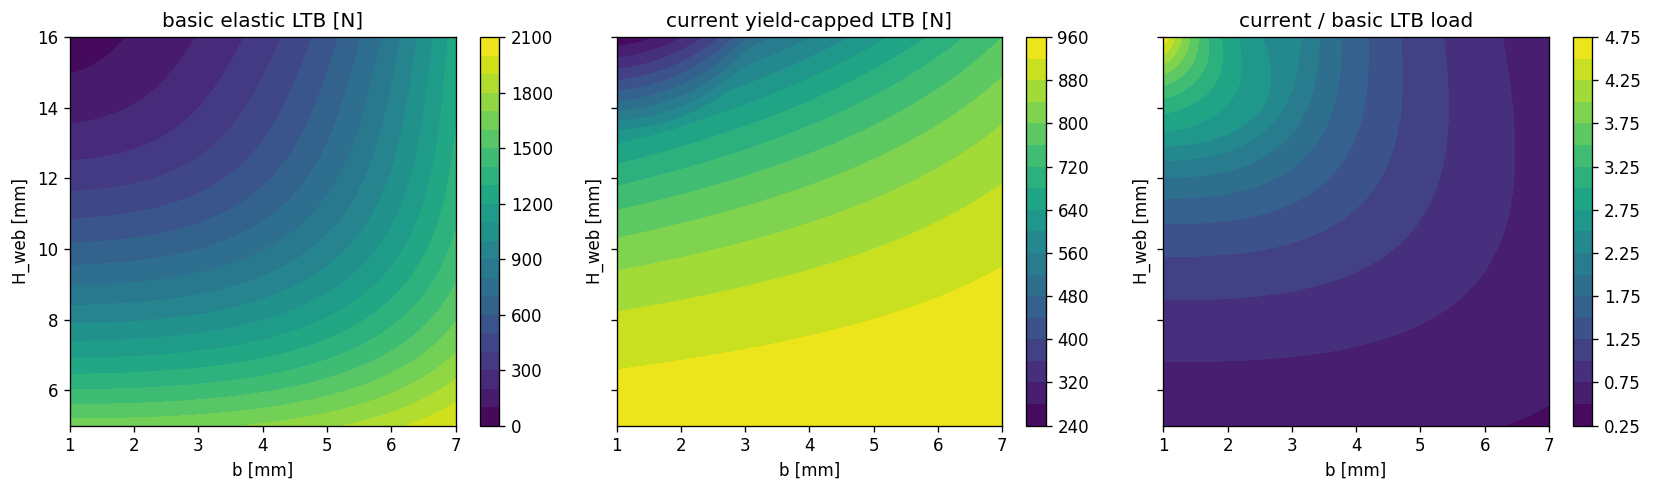

Basic-assumption optimum: b=1.88, H_web=8.58, str/w=38.9 N/g
Current-assumption optimum: b=1.13, H_web=13.16, str/w=48.6 N/g
The exact current class checkpoint uses the finer 0.05 mm grid below.


In [9]:
def P_LTB_basic(p):
    """Basic elastic LTB: k=1, thin-strip J, no warping/load height/yield cap."""
    Lb = L/1e3
    J_thin = (p["h"]*p["b"]**3 + 2*p["B"]*p["tf"]**3)/3
    R_basic = (Lb**2*G*J_thin)/(np.pi**2*E*p["Iy"])
    Mcr = C1*np.pi**2*E*p["Iy"]/Lb**2 * np.sqrt(R_basic)
    return 4*Mcr/(L/1e3)

SY_KEY, K_KEY, TAU_KEY = 6.683e+07, 0.377, 1.676e+07
b_key = np.linspace(1.0, 7.0, 90)
H_key = np.linspace(5.0, 16.0, 90)
BB_key, HH_key = np.meshgrid(b_key, H_key)
X_key = np.column_stack([BB_key.ravel(), HH_key.ravel()])

ltb_basic, ltb_current, sw_basic, sw_current = [], [], [], []
for bq, Hq in X_key:
    pq = section_props(bq, Hq)
    Pbq = P_bend(pq, SY_KEY)
    Psq = P_sep(pq, TAU_KEY)
    Pbasic = P_LTB_basic(pq)
    Pcurrent = P_LTB(pq, SY_KEY, K_KEY)
    ltb_basic.append(Pbasic)
    ltb_current.append(Pcurrent)
    sw_basic.append(min(Pbq, Psq, Pbasic)/estimated_mass_g(bq, Hq))
    sw_current.append(min(Pbq, Psq, Pcurrent)/estimated_mass_g(bq, Hq))

ltb_basic = np.asarray(ltb_basic)
ltb_current = np.asarray(ltb_current)
sw_basic = np.asarray(sw_basic)
sw_current = np.asarray(sw_current)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharex=True, sharey=True)
maps = [
    (ltb_basic, "basic elastic LTB [N]"),
    (ltb_current, "current yield-capped LTB [N]"),
    (ltb_current/ltb_basic, "current / basic LTB load"),
]
for ax, (values, title) in zip(axes, maps):
    cf = ax.contourf(BB_key, HH_key, values.reshape(BB_key.shape), levels=20)
    fig.colorbar(cf, ax=ax)
    ax.set_xlabel("b [mm]"); ax.set_ylabel("H_web [mm]"); ax.set_title(title)
plt.tight_layout(); plt.show()

i_basic = int(np.argmax(sw_basic))
i_current = int(np.argmax(sw_current))
print("Basic-assumption optimum:",
      f"b={X_key[i_basic,0]:.2f}, H_web={X_key[i_basic,1]:.2f}, "
      f"str/w={sw_basic[i_basic]:.1f} N/g")
print("Current-assumption optimum:",
      f"b={X_key[i_current,0]:.2f}, H_web={X_key[i_current,1]:.2f}, "
      f"str/w={sw_current[i_current]:.1f} N/g")
print("The exact current class checkpoint uses the finer 0.05 mm grid below.")

## 7. Diagnose the model before fitting it

The plots below use one common scale. Point color is the predicted dominant
mode; marker shape is the observed note category. Beam IDs let you connect
every miss to the full note table.

One data-handling note before you trust the markers: the classifier below reads
the test engineer's free-text notes, which spell separation "seperation" — match
the data, not the dictionary, or the separation beams silently disappear into
the fracture bin. Beam 7 is a mixed case (a complete central fracture plus a
small secondary flange separation); the rule below counts a note as separation
only when it does not also report a complete central fracture.

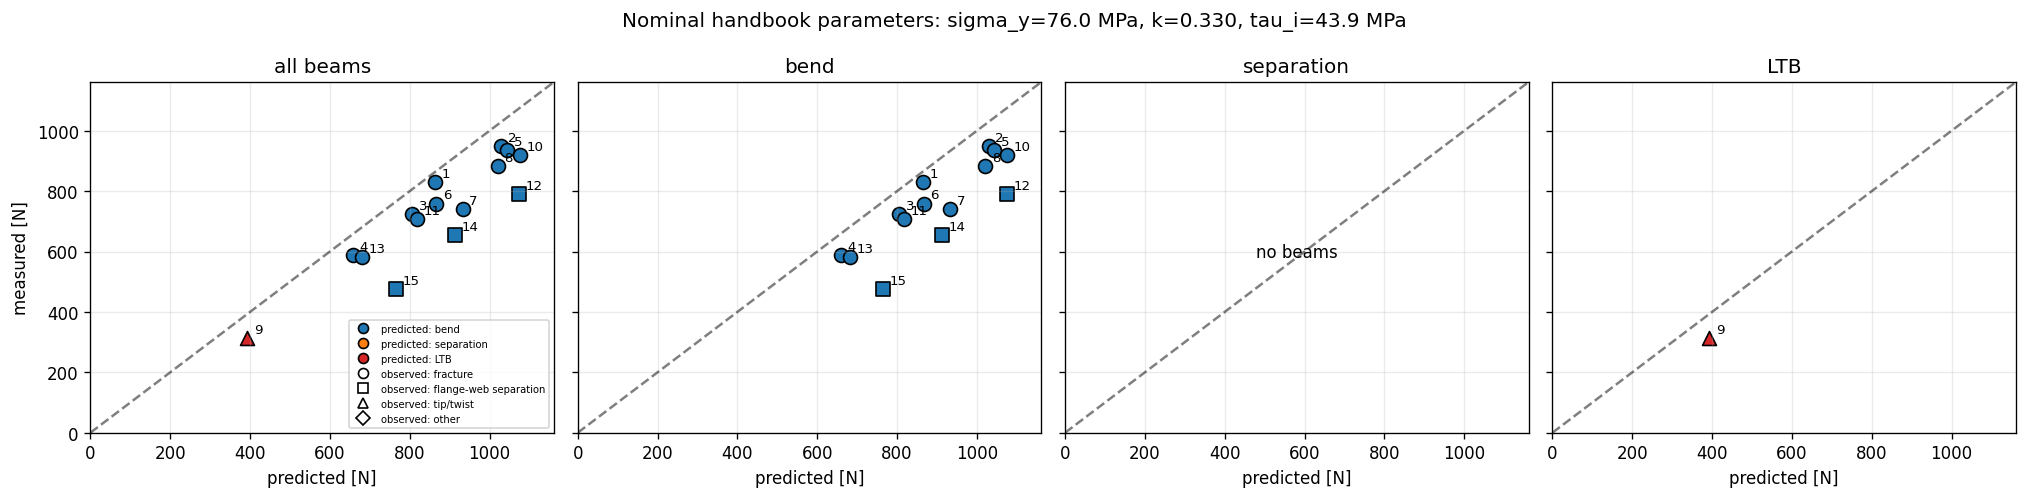

 beam_id    b    H  strength_N  predicted_N  residual_pct mode_proxy        observed_class                                                                                                                                   failure_note
       1 7.00 16.0       829.4        863.8           4.1       bend              fracture                                                                                       Complete vertical fracture across the center of the beam
       2 7.00 10.5       948.8       1029.2           8.5       bend              fracture                                                                                       Complete vertical fracture across the center of the beam
       3 4.85 14.4       724.1        805.8          11.3       bend              fracture                                                               Vertical fracture on the bottom of the beam, but not completely through the beam
       4 3.25 15.1       588.8        658.3          11.8       

In [10]:
def observed_note_class(note):
    s = str(note).lower()
    # the notes spell it "seperation" -- match the data, not the dictionary;
    # a note that also reports a complete central fracture counts as fracture
    is_sep = ("separ" in s) or ("seper" in s) or ("peel" in s)
    if is_sep and "vertical fracture across" not in s:
        return "flange-web separation"
    if any(word in s for word in ("flip", "tip", "twist", "buckl")):
        return "tip/twist"
    if "fract" in s or "vertical" in s:
        return "fracture"
    return "other"

MODE_ORDER = ["bend", "separation", "LTB"]
MODE_COLOR = {"bend": "tab:blue", "separation": "tab:orange", "LTB": "tab:red"}
OBS_MARKER = {"fracture": "o", "flange-web separation": "s", "tip/twist": "^", "other": "D"}
from matplotlib.lines import Line2D

def diagnostic_plots(sy, k, tau_i, label):
    d = df.copy()
    d["predicted_N"] = [capacity(b, H, sy, k, tau_i) for b, H in zip(d.b, d.H)]
    d["mode_proxy"] = [gov_mode(b, H, sy, k, tau_i) for b, H in zip(d.b, d.H)]
    d["observed_class"] = d.failure_note.map(observed_note_class)
    d["residual_pct"] = 100*(d.predicted_N/d.strength_N - 1)
    hi = 1.08*max(d.predicted_N.max(), d.strength_N.max())
    fig, axes = plt.subplots(1, 4, figsize=(17, 4.2), sharex=True, sharey=True)
    panels = [("all beams", d)] + [(mode, d[d.mode_proxy == mode]) for mode in MODE_ORDER]
    for ax, (title, sub) in zip(axes, panels):
        for _, row in sub.iterrows():
            ax.scatter(row.predicted_N, row.strength_N, s=70,
                       c=MODE_COLOR[row.mode_proxy],
                       marker=OBS_MARKER[row.observed_class], edgecolor="k")
            ax.annotate(str(int(row.beam_id)), (row.predicted_N, row.strength_N),
                        xytext=(4, 3), textcoords="offset points", fontsize=8)
        ax.plot([0, hi], [0, hi], "k--", alpha=0.5)
        ax.set_title(title); ax.set_xlabel("predicted [N]")
        ax.grid(alpha=0.25); ax.set_xlim(0, hi); ax.set_ylim(0, hi)
        if sub.empty:
            ax.text(0.5, 0.5, "no beams", transform=ax.transAxes, ha="center")
    axes[0].set_ylabel("measured [N]")
    legend_handles = [
        Line2D([0], [0], marker="o", color="none", markerfacecolor=color,
               markeredgecolor="k", label=f"predicted: {mode}")
        for mode, color in MODE_COLOR.items()
    ] + [
        Line2D([0], [0], marker=marker, color="k", linestyle="none",
               markerfacecolor="white", label=f"observed: {obs}")
        for obs, marker in OBS_MARKER.items()
    ]
    axes[0].legend(handles=legend_handles, fontsize=6, loc="lower right")
    fig.suptitle(f"{label}: sigma_y={sy/1e6:.1f} MPa, k={k:.3f}, tau_i={tau_i/1e6:.1f} MPa")
    plt.tight_layout(); plt.show()
    cols = ["beam_id", "b", "H", "strength_N", "predicted_N", "residual_pct",
            "mode_proxy", "observed_class", "failure_note"]
    print(d[cols].round({"b": 2, "H": 2, "strength_N": 1,
                         "predicted_N": 1, "residual_pct": 1}).to_string(index=False))
    mape = d.residual_pct.abs().mean()
    print(f"\n{label} MAPE = {mape:.1f}%")
    return d, float(mape)

diag_nominal, mape_nom = diagnostic_plots(SY, K_LTB, TAU_I, "Nominal handbook parameters")
df["cap_nominal"] = diag_nominal.predicted_N
print(f"CHECKPOINT: nominal error should be about 21% MAPE.")

## 8. Tune by hand before optimizing

Change the three values and rerun this cell. Try to improve the parity plot,
but watch which failure notes and predicted modes each change helps or hurts.

- `TRY_SY_MPA` moves the flexural-yield side.
- `TRY_K` mostly moves the LTB-limited beams.
- `TRY_TAU_MPA` moves only the separation limit -- watch beams 12 and 14, the
  two whose notes say a flange separated from the web (beam 7 shows a partial,
  secondary separation after its central fracture).

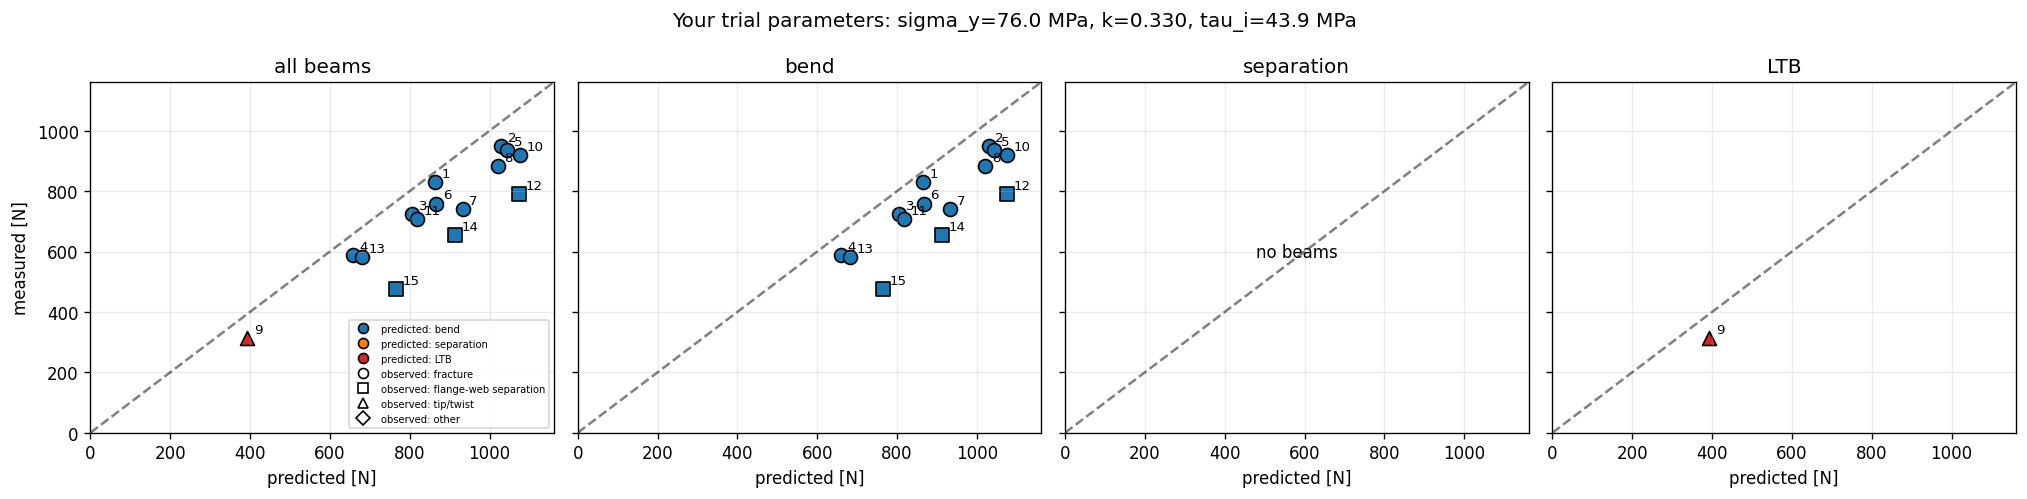

 beam_id    b    H  strength_N  predicted_N  residual_pct mode_proxy        observed_class                                                                                                                                   failure_note
       1 7.00 16.0       829.4        863.8           4.1       bend              fracture                                                                                       Complete vertical fracture across the center of the beam
       2 7.00 10.5       948.8       1029.2           8.5       bend              fracture                                                                                       Complete vertical fracture across the center of the beam
       3 4.85 14.4       724.1        805.8          11.3       bend              fracture                                                               Vertical fracture on the bottom of the beam, but not completely through the beam
       4 3.25 15.1       588.8        658.3          11.8       

In [11]:
TRY_SY_MPA = 76.0    # edit
TRY_K = 0.33         # edit
TRY_TAU_MPA = 43.9   # edit -- the printed-interface strength guess

diag_try, mape_try = diagnostic_plots(
    TRY_SY_MPA*1e6, TRY_K, TRY_TAU_MPA*1e6, "Your trial parameters")

## 9. Calibrate the three parameters

Now automate the search. The loss is mean squared log-error, so comparable
percentage misses receive comparable weight:

$$L(\sigma_y,k,\tau_i)=\frac{1}{14}\sum_{i=1}^{14}
\left(\ln P_{pred,i}-\ln P_{meas,i}\right)^2.$$

Fill in the loss. A coarse search and Nelder-Mead polish are provided.

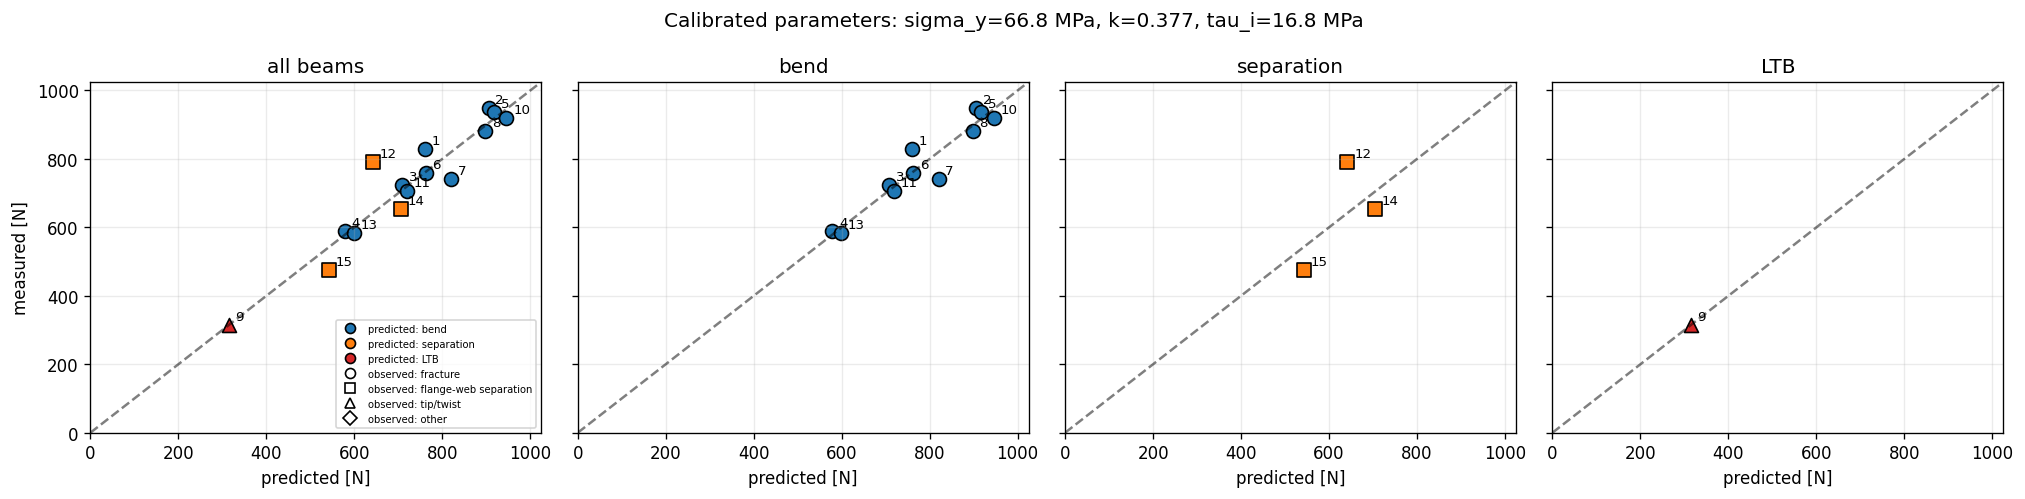

 beam_id    b    H  strength_N  predicted_N  residual_pct mode_proxy        observed_class                                                                                                                                   failure_note
       1 7.00 16.0       829.4        759.6          -8.4       bend              fracture                                                                                       Complete vertical fracture across the center of the beam
       2 7.00 10.5       948.8        905.0          -4.6       bend              fracture                                                                                       Complete vertical fracture across the center of the beam
       3 4.85 14.4       724.1        708.6          -2.1       bend              fracture                                                               Vertical fracture on the bottom of the beam, but not completely through the beam
       4 3.25 15.1       588.8        578.8          -1.7       

In [12]:
from scipy.optimize import minimize

def loss(theta):
    sy, k, tau_i = theta
    if not (30e6 < sy < 150e6 and 0.05 < k < 1.5 and 3e6 < tau_i < 45e6):
        return 1e9
    pred = np.array([capacity(b, H, sy, k, tau_i) for b, H in zip(df.b, df.H)])
    return float(np.mean((np.log(pred) - np.log(df.strength_N.values))**2))

grid = [(sy, k, ti) for sy in np.linspace(55e6, 100e6, 19)
        for k in np.linspace(0.10, 0.90, 17)
        for ti in (8e6, 12e6, 17.5e6, 25e6, 43.9e6)]
theta0 = min(grid, key=loss)
res = minimize(loss, theta0, method="Nelder-Mead",
               options=dict(xatol=1e-4, fatol=1e-10, maxiter=4000))
SY_CAL, K_CAL, TAU_CAL = res.x
diag_cal, mape_cal = diagnostic_plots(SY_CAL, K_CAL, TAU_CAL, "Calibrated parameters")
df["cap_cal"] = diag_cal.predicted_N
print(f"calibrated: sigma_y = {SY_CAL/1e6:.1f} MPa, k = {K_CAL:.3f}, "
      f"tau_i = {TAU_CAL/1e6:.2f} MPa")
print(f"CHECKPOINT: sigma_y = 66.8 MPa, k = 0.377, tau_i = 16.76 MPa, "
      f"error = 5.3% MAPE. Your error: {mape_cal:.1f}%.")
print("Within about 1% of these values counts as matching -- Nelder-Mead and")
print("library versions wobble the last digit. Farther off than that, check")
print("your work or talk to a TA.")
print("tau_i lands FAR below the 43.9 MPa bulk guess: the bond along the")
print("printed layer lines, not the bulk plastic, is what fails. That number")
print("exists in no handbook.")

Do not read a fitted parameter as a direct material measurement. Decide
whether each change corrects a plausible numerical assumption or compensates
for missing physics. The failure-note table is evidence for that distinction.

## 10. Optimize the equation design

Search the design box (b from 1.0 to 7.0 mm, H_web from 5.0 to 16.0 mm) for
the best predicted strength-to-weight under the
calibrated empirical model. Fill in the objective.

In [13]:
best = (None, None, -1)
for b in np.arange(1.0, 7.01, 0.05):
    for H in np.arange(5.0, 16.01, 0.05):
        cap = capacity(b, H, SY_CAL, K_CAL, TAU_CAL)
        sw = cap / estimated_mass_g(b, H)
        if sw > best[2]:
            best = (round(b, 2), round(H, 2), sw)
b_eq, H_eq, sw_eq = best
mode_cal = gov_mode(b_eq, H_eq, SY_CAL, K_CAL, TAU_CAL)
mode_nom = gov_mode(b_eq, H_eq, SY, K_LTB, TAU_I)
p_eq = section_props(b_eq, H_eq)
print(f"EQUATION DESIGN: b={b_eq} mm, H_web={H_eq} mm, predicted {sw_eq:.1f} N/g")
print(f"dominant-mode proxy at this geometry: calibrated={mode_cal}, nominal={mode_nom}")
print("mode capacities at the optimum, calibrated: "
      f"P_bend={P_bend(p_eq, SY_CAL):.0f} N, "
      f"P_sep={P_sep(p_eq, TAU_CAL):.0f} N, "
      f"P_LTB={P_LTB(p_eq, SY_CAL, K_CAL):.0f} N")
print("CHECKPOINT: b = 1.10, H_web = 13.25, predicted 48.7 N/g.")

EQUATION DESIGN: b=1.1 mm, H_web=13.25 mm, predicted 48.7 N/g
dominant-mode proxy at this geometry: calibrated=LTB, nominal=bend
mode capacities at the optimum, calibrated: P_bend=621 N, P_sep=623 N, P_LTB=618 N
CHECKPOINT: b = 1.10, H_web = 13.25, predicted 48.7 N/g.


### What happens to this design

Staff query it against the **ground truth model**: a statistical model fit to
a large prior campaign of real print-and-bend tests on this exact geometry and
fixture, then frozen before the course began. It stands in for the testing
machine so
the class's limited print-and-test budget is not spent re-testing the same two
class-common designs — the strength it returns is its prediction of what a real
test would measure, not a new broken beam. The beam that does get printed and
broken for real is the one your group commits to in Submission 1.

Because the data, constants, and grid above are fixed, every group's optimizer
lands on this same design. The query is therefore one shared data point for the
whole class; the returned strength appears at the start of Pre-lab 2. Your own
choices take over in Submission 1.

## Memo questions

Answer these in markdown cells at the end of this notebook. The answers stay
here — this notebook is turned in alongside Submission 1 and the answers are
graded with it. Do not re-answer them in the Submission 1 memo.

1. Compare measured and estimated masses. Name one physical reason they differ,
   and explain why the pre-print optimizer still uses estimated mass.
2. The final cell prints the dominant-mode proxy and all three mode capacities
   at the equation design. How close is the runner-up mode? What does that
   margin (or lack of one) say about how literally to read a single proxy
   label at an optimum found by maximizing a minimum of surfaces?
3. For $\sigma_y$, `k`, and $\tau_i$, decide whether calibration is a
   correction to a number or the measurement of a property no handbook has.
   Cite specific residuals and failure notes from the diagnostic table.
4. The optimum sits one grid notch off the thin-`b` edge of the box, pulled
   back from b = 1.0 by the calibrated LTB surface. Which observed failures --
   beam 15's note above all -- should reduce your trust in that neighborhood?

5. From section 1b: which trace shapes separate abrupt fracture from gradual
   failure? Make the call on beam 9 — material strength, fixture/stability
   artifact, or both — and say how a model trained on that 314.4 N should
   treat it.

Use the final design output, the nominal/calibrated plots, and beam IDs with
their full failure notes. No additional optimization code is required.

## KEY: memo targets

1. Measured mass includes print and measurement variation; estimated mass is a
   nominal-geometry quantity available before printing. Students should not
   silently mix denominators when comparing str/w.
2. At the calibrated optimum all three mode capacities land within about 1%
   of each other (roughly 621 / 623 / 618 N for bend / separation / LTB); the
   "LTB" label is an artifact of the tie-break thresholds. Optimizing a min() of capacity surfaces drives the
   design toward mode intersections — exactly where a single proxy label
   deserves the least trust. Treat the label as a dominant-mode proxy, not an
   observed fracture diagnosis.
3. A defensible reading is: effective $\sigma_y$ is partly a correction for
   printed material versus a handbook coupon; `k` is a fixture correction but
   also absorbs idealized LTB assumptions; $\tau_i$ is neither -- it is the
   *measurement* of a real printed-interface property that no handbook lists
   (the faculty model-selection study back-calculates it at 15-21 MPa across
   the campaign separations, CoV 15%).
4. Beam 15's flange-web separation at b = 1.0 is the direct warning -- the
   calibrated model still overpredicts that beam by about 14%. The model
   has no joint-separation or local plate-failure equation, so an edge optimum
   is extrapolation into its weakest physics.